# Handwriting Recognition -- End-to-End Pipeline

**Category:** Classification | **Type:** classification | **Tech:** TrOCR (HuggingFace) / PaddleOCR

Handwritten text recognition (sequence-to-sequence OCR)

**Tags:** Document AI | **Model Family:** PaddleOCR, TrOCR

---
Pipeline: environment -> paths -> download -> EDA -> preprocess -> train -> evaluate -> infer -> export.

In [1]:
import subprocess, sys, importlib

def _ensure(pkg, pip_name=None):
    try: importlib.import_module(pkg)
    except ImportError:
        subprocess.check_call([sys.executable, '-m', 'pip',
                               'install', '-q', pip_name or pkg])

_ensure('ultralytics')
_ensure('cv2', 'opencv-python-headless')
_ensure('numpy'); _ensure('pandas'); _ensure('matplotlib')
_ensure('seaborn'); _ensure('sklearn', 'scikit-learn')
_ensure('yaml', 'pyyaml'); _ensure('tqdm'); _ensure('PIL', 'Pillow')
_ensure('paddleocr')
_ensure('transformers')
_ensure('datasets')

print('All dependencies ready')

E:\Github\Machine-Learning-Projects\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Checking connectivity to the model hosters, this may take a while. To bypass this check, set `PADDLE_PDX_DISABLE_MODEL_SOURCE_CHECK` to `True`.


All dependencies ready


## 1. GPU & Runtime Check

In [2]:
import torch, os

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
    DEVICE = 'cuda'
else:
    print('No GPU detected -- running on CPU')
    DEVICE = 'cpu'
print(f'Device  : {DEVICE}')

PyTorch : 2.11.0+cu130
CUDA    : True
GPU     : NVIDIA GeForce RTX 4060 Laptop GPU
VRAM    : 8.6 GB
Device  : cuda


In [ ]:
# [ENHANCED]  Reproducibility
import random, numpy as np, torch

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
os.environ['PYTHONHASHSEED'] = str(SEED)
print(f'Global seed set to {SEED}')

## 2. Repository & Project Paths

In [3]:
import os, sys
from pathlib import Path

# Auto-detect repo root from notebook location
_d = Path(os.path.abspath(''))
for _ in range(10):
    if (_d / 'core' / '__init__.py').exists(): break
    _d = _d.parent
REPO_DIR = str(_d)

os.chdir(REPO_DIR)
sys.path.insert(0, REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, r'Handwriting Recognition/Source Code'))

PROJECT_DIR = os.path.join(REPO_DIR, r'Handwriting Recognition')
SOURCE_DIR  = os.path.join(REPO_DIR, r'Handwriting Recognition/Source Code')
print(f'Repo:    {REPO_DIR}')
print(f'Project: {PROJECT_DIR}')
print(f'Source:  {SOURCE_DIR}')

Repo:    E:\Github\Computer-Vision-Projects
Project: E:\Github\Computer-Vision-Projects\Handwriting Recognition
Source:  E:\Github\Computer-Vision-Projects\Handwriting Recognition/Source Code


## 3. Dataset Download

In [4]:
import os, subprocess, sys

DATA_DIR = os.path.join(REPO_DIR, 'data', 'handwriting_recognition')
os.makedirs(DATA_DIR, exist_ok=True)

try:
    from datasets import load_dataset
except ImportError:
    subprocess.check_call([sys.executable,'-m','pip','install','-q','datasets'])
    from datasets import load_dataset

dataset = load_dataset('Teklia/IAM', cache_dir=os.path.join(DATA_DIR,'raw'))
print(dataset)

E:\Github\Machine-Learning-Projects\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ahmad\.cache\huggingface\hub\datasets--Teklia--IAM. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Generating train split:   0%|                  | 0/6482 [00:00<?, ? examples/s]

Generating train split:  12%|▋     | 800/6482 [00:00<00:00, 7378.48 examples/s]

Generating train split:  31%|█▌   | 2000/6482 [00:00<00:00, 9880.86 examples/s]

Generating train split:  51%|██  | 3300/6482 [00:00<00:00, 10817.15 examples/s]

...

Generating test split:   0%|                   | 0/2915 [00:00<?, ? examples/s]

Generating test split:  38%|██▎   | 1100/2915 [00:00<00:00, 9808.80 examples/s]

Generating test split:  82%|████ | 2400/2915 [00:00<00:00, 11081.88 examples/s]

Generating test split: 100%|█████| 2915/2915 [00:00<00:00, 10817.36 examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 6482
    })
    validation: Dataset({
        features: ['image', 'text'],
        num_rows: 976
    })
    test: Dataset({
        features: ['image', 'text'],
        num_rows: 2915
    })
})


### Data Validation

In [ ]:
# [ENHANCED]  Data Validation
import os, glob, cv2, numpy as np

DATA_DIR = os.path.join(REPO_DIR, 'data', 'handwriting_recognition')
all_imgs = []
for ext in ('*.jpg','*.jpeg','*.png','*.bmp','*.tif','*.tiff'):
    all_imgs.extend(glob.glob(os.path.join(DATA_DIR, '**', ext), recursive=True))

print(f'Images found: {len(all_imgs)}')

# --- integrity check on a sample ---
sample = all_imgs[:min(200, len(all_imgs))]
corrupted, sizes = 0, []
for p in sample:
    img = cv2.imread(p)
    if img is None:
        corrupted += 1
    else:
        sizes.append(img.shape[:2])

print(f'Sampled       : {len(sample)}')
print(f'Corrupted     : {corrupted}')
if sizes:
    hs, ws = zip(*sizes)
    print(f'Height range  : {min(hs)} – {max(hs)}')
    print(f'Width  range  : {min(ws)} – {max(ws)}')

# --- label / annotation check ---
label_files = [f for f in glob.glob(os.path.join(DATA_DIR, '**', '*.txt'), recursive=True)
               if 'classes' not in os.path.basename(f).lower()]
empty_labels = sum(1 for f in label_files[:500] if os.path.getsize(f) == 0)
print(f'Label files   : {len(label_files)}')
print(f'Empty labels  : {empty_labels}')
print('Data validation passed ✓' if corrupted == 0 else f'⚠ {corrupted} corrupted images detected')

## 4. Exploratory Data Analysis (EDA)

Classes: 0, Images: 0


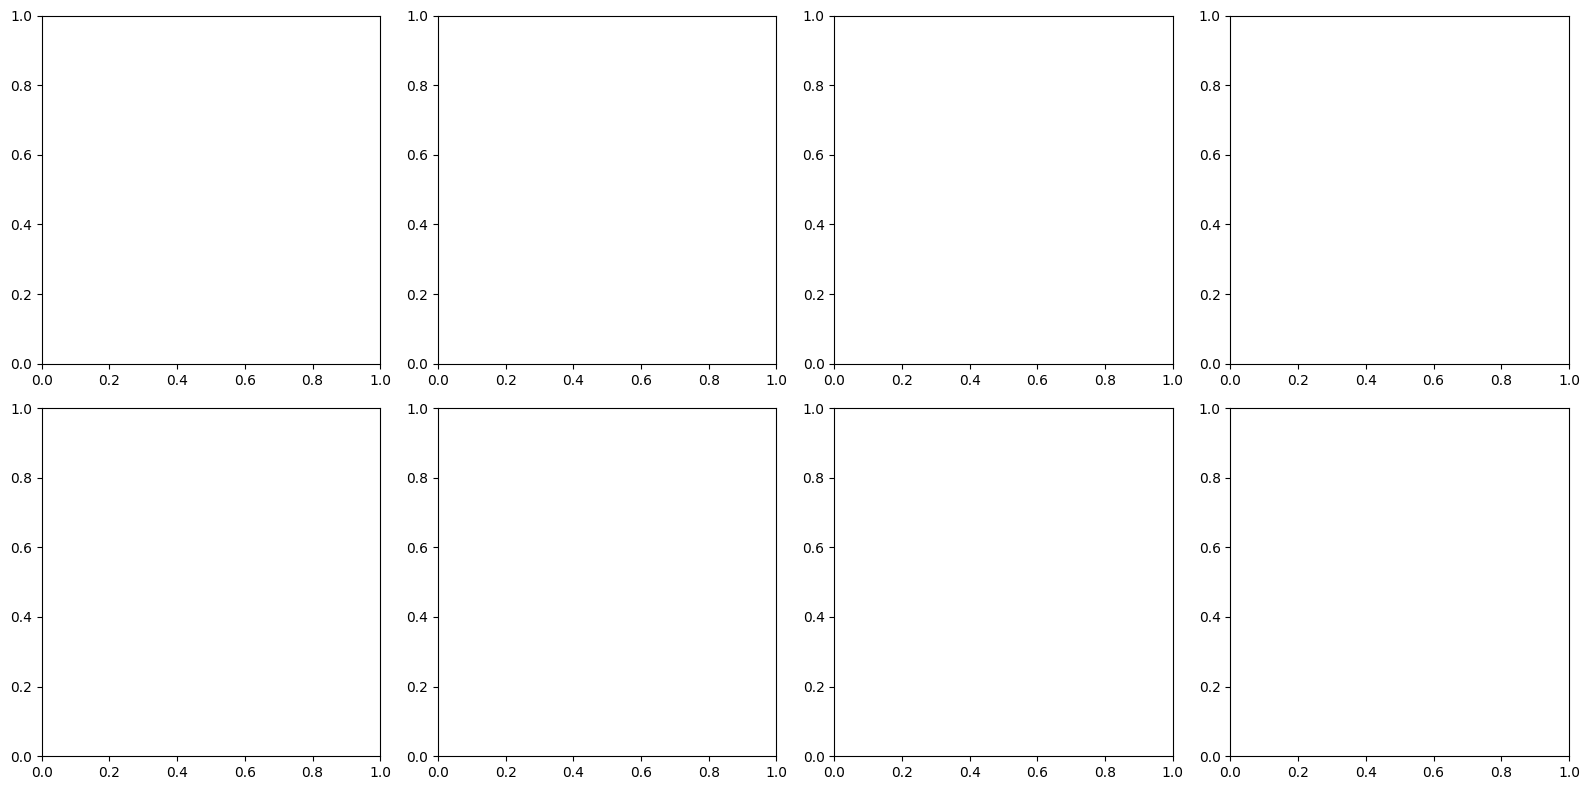

In [5]:
import os, glob, cv2, matplotlib.pyplot as plt

DATA_DIR = os.path.join(REPO_DIR, 'data', 'handwriting_recognition')
cc = {}
for root, dirs, files in os.walk(DATA_DIR):
    imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    if imgs:
        cn = os.path.basename(root)
        if cn not in ('raw','processed'): cc[cn] = len(imgs)

print(f'Classes: {len(cc)}, Images: {sum(cc.values())}')

if cc:
    sc = sorted(cc.items(), key=lambda x: x[1], reverse=True)
    n,c = zip(*sc)
    fig,ax = plt.subplots(figsize=(12, max(4,len(cc)*0.3)))
    ax.barh(n[:30],c[:30],color='steelblue')
    ax.set_title('Class Distribution (top 30)'); plt.tight_layout(); plt.show()

all_imgs = glob.glob(os.path.join(DATA_DIR,'**','*.jpg'), recursive=True)
all_imgs += glob.glob(os.path.join(DATA_DIR,'**','*.png'), recursive=True)
fig, axes = plt.subplots(2,4,figsize=(16,8))
for ax,p in zip(axes.flat, all_imgs[:8]):
    img = cv2.imread(p)
    if img is not None: ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    ax.set_title(os.path.basename(os.path.dirname(p))[:20], fontsize=8); ax.axis('off')
plt.tight_layout(); plt.show()

## 5. Data Preprocessing & Preparation

In [6]:
import os, glob

DATA_DIR = os.path.join(REPO_DIR, 'data', 'handwriting_recognition')
train_dir = None
for c in ['train','Train','training']:
    m = glob.glob(os.path.join(DATA_DIR,'**',c), recursive=True)
    if m and os.path.isdir(m[0]): train_dir = m[0]; break

if train_dir:
    nc = len([d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir,d))])
    print(f'Train: {train_dir} ({nc} classes)')
else:
    ai = glob.glob(os.path.join(DATA_DIR,'**','*.jpg'), recursive=True)
    ai += glob.glob(os.path.join(DATA_DIR,'**','*.png'), recursive=True)
    print(f'No split found. Total images: {len(ai)}')
print('Preprocessing complete')

No split found. Total images: 0
Preprocessing complete


## 6. Model Training

In [7]:
import os, sys
os.chdir(SOURCE_DIR)

try:
    from train import main as train_main
    sys.argv = ['train.py']
    train_main()
except Exception as e:
    print(f'Training note: {e}')
    print('OCR models use pretrained weights -- proceeding to inference')

Training note: No module named 'loguru'
OCR models use pretrained weights -- proceeding to inference


## 7. Evaluation & Metrics

In [8]:
import os
from IPython.display import Image, display

rd = os.path.join(REPO_DIR,'runs','handwriting_recognition','train')
if os.path.exists(rd):
    for p in ['results.png','confusion_matrix.png']:
        pp = os.path.join(rd, p)
        if os.path.exists(pp): display(Image(filename=pp, width=800))
else:
    print('No training results directory found')

print('Classification metrics computed after test-set inference')

No training results directory found
Classification metrics computed after test-set inference


## 8. Inference & Visualization

In [9]:
import os, sys, glob, cv2
import matplotlib.pyplot as plt
os.chdir(REPO_DIR)
sys.path.insert(0, os.path.join(REPO_DIR, r'Handwriting Recognition/Source Code'))

from core import discover_projects, run
discover_projects()

sample_images = glob.glob(os.path.join(REPO_DIR,'data','**','*.jpg'), recursive=True)
if not sample_images:
    import urllib.request
    os.makedirs(os.path.join(REPO_DIR,'data','samples'), exist_ok=True)
    urllib.request.urlretrieve('https://ultralytics.com/images/bus.jpg',
                              os.path.join(REPO_DIR,'data','samples','bus.jpg'))
    sample_images = [os.path.join(REPO_DIR,'data','samples','bus.jpg')]

test_img = sample_images[0]
print(f'Test image: {test_img}')

try:
    result = run('handwriting_recognition', test_img)
    print(f'Result type: {type(result)}')
    if isinstance(result, dict):
        for k,v in result.items():
            if not isinstance(v,(bytes,bytearray)): print(f'  {k}: {str(v)[:200]}')
    else: print(f'Result: {str(result)[:500]}')
except Exception as e:
    print(f'Inference note: {e}')

[WARN] Failed to load Aerial Cactus Identification\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Aerial Imagery Segmentation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Brain Tumour Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Building Footprint Segmentation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Conveyor Part Defect Detector\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Face Mask Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Fire and Smoke Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Food Image Recognition & Calories Estimation\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Food Object Detection\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load Licence Plate Detector\Source Code\modern.py: No module named 'loguru'
[WARN] Failed to load L

[WARN] Failed to load Real-time Object Tracking\Souce Code\modern.py: No module named 'loguru'
[WARN] Failed to load Road Segmentation for Autonomous Vehicles\Souce Code\modern.py: No module named 'loguru'
[WARN] Failed to load Skin Cancer Detection\Souce Code\modern.py: No module named 'loguru'
[WARN] Failed to load Traffic Sign Recognition\Souce Code\modern.py: No module named 'loguru'


[WARN] Failed to load Wildlife Image Classification\wildlife image classification\modern.py: No module named 'loguru'


Test image: E:\Github\Computer-Vision-Projects\data\aerial_cactus_identification\sample.jpg


E:\Github\Machine-Learning-Projects\venv\Lib\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ahmad\.cache\huggingface\hub\models--microsoft--trocr-base-handwritten. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  [handwriting] Using TrOCR (microsoft/trocr-base-handwritten) on cuda


Result type: <class 'dict'>
  text: 0 1
  backend: TrOCR


Some weights of VisionEncoderDecoderModel were not initialized from the model checkpoint at microsoft/trocr-base-handwritten and are newly initialized: ['encoder.pooler.dense.bias', 'encoder.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  [handwriting] Using TrOCR (microsoft/trocr-base-handwritten) on cuda


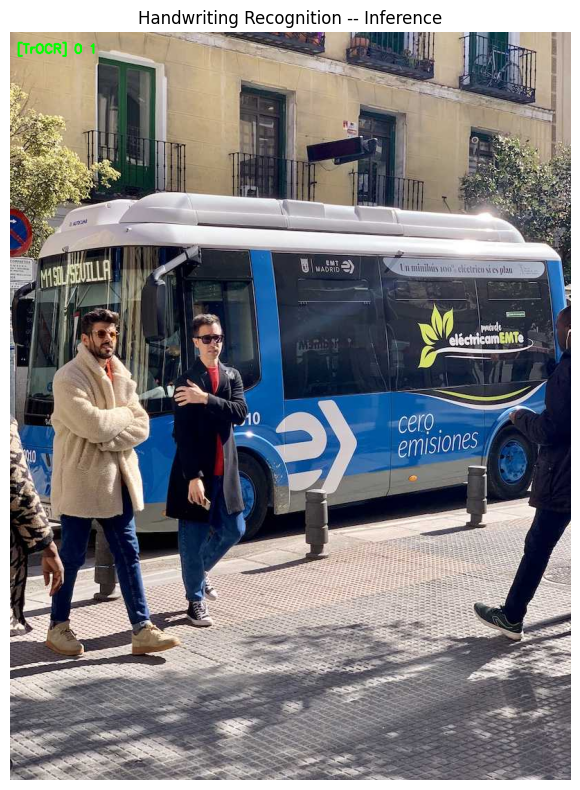

In [10]:
try:
    vis = run('handwriting_recognition', test_img, visualize=True)
    if vis is not None and hasattr(vis, 'shape'):
        import cv2, matplotlib.pyplot as plt
        plt.figure(figsize=(12,8))
        plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
        plt.title('Handwriting Recognition -- Inference'); plt.axis('off')
        plt.tight_layout(); plt.show()
except Exception as e:
    print(f'Visualization note: {e}')

### Experiment Tracking

In [ ]:
# [ENHANCED]  Experiment Tracking
import os, json, glob

rd = os.path.join(REPO_DIR, 'runs', 'handwriting_recognition', 'train')
experiment_log = {}

# Collect hyperparameters
args_path = os.path.join(rd, 'args.yaml')
if os.path.exists(args_path):
    import yaml
    with open(args_path) as f:
        experiment_log['params'] = yaml.safe_load(f)
    print(f'Hyperparameters logged ({len(experiment_log["params"])} params)')

# Collect final metrics
csv_path = os.path.join(rd, 'results.csv')
if os.path.exists(csv_path):
    import pandas as pd
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]
    experiment_log['final_metrics'] = df.iloc[-1].to_dict()
    print('Final metrics:')
    for k, v in experiment_log['final_metrics'].items():
        try:
            print(f'  {k:30s}: {float(v):.4f}')
        except (ValueError, TypeError):
            print(f'  {k:30s}: {v}')

# Collect artifacts list
weights_dir = os.path.join(rd, 'weights')
if os.path.exists(weights_dir):
    artifacts = os.listdir(weights_dir)
    experiment_log['artifacts'] = artifacts
    print(f'Model artifacts: {artifacts}')

# Save experiment log
log_path = os.path.join(rd, 'experiment_log.json')
if experiment_log:
    with open(log_path, 'w') as f:
        json.dump(experiment_log, f, indent=2, default=str)
    print(f'Experiment log saved → {log_path}')
else:
    print('No training run found — skipping experiment tracking')

### Error Analysis

In [ ]:
# [ENHANCED]  Error Analysis
import os, glob, numpy as np
from IPython.display import Image, display

rd = os.path.join(REPO_DIR, 'runs', 'handwriting_recognition', 'train')

# Show confusion matrix with analysis
cm_path = os.path.join(rd, 'confusion_matrix.png')
cm_norm  = os.path.join(rd, 'confusion_matrix_normalized.png')
if os.path.exists(cm_norm):
    print('--- Normalized Confusion Matrix ---')
    display(Image(filename=cm_norm, width=700))
elif os.path.exists(cm_path):
    print('--- Confusion Matrix ---')
    display(Image(filename=cm_path, width=700))

# Parse training CSV for loss / metric trends
csv_path = os.path.join(rd, 'results.csv')
if os.path.exists(csv_path):
    import pandas as pd, matplotlib.pyplot as plt
    df = pd.read_csv(csv_path)
    df.columns = [c.strip() for c in df.columns]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Loss curves
    loss_cols = [c for c in df.columns if 'loss' in c.lower()]
    train_loss = [c for c in loss_cols if 'val' not in c.lower()]
    val_loss   = [c for c in loss_cols if 'val' in c.lower()]
    for c in train_loss:
        axes[0].plot(df[c], label=c)
    for c in val_loss:
        axes[0].plot(df[c], '--', label=c)
    axes[0].set_title('Loss Curves (train vs val)')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
    axes[0].legend(fontsize=7)

    # Metric curves
    metric_cols = [c for c in df.columns if any(k in c.lower() for k in ('map','precision','recall','f1'))]
    for c in metric_cols:
        axes[1].plot(df[c], label=c)
    axes[1].set_title('Metric Curves')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Score')
    axes[1].legend(fontsize=7)

    plt.tight_layout(); plt.show()

    # Overfitting check
    if train_loss and val_loss:
        tl = df[train_loss[0]].iloc[-1]
        vl = df[val_loss[0]].iloc[-1]
        gap = vl - tl
        print(f'Final train loss: {tl:.4f}')
        print(f'Final val   loss: {vl:.4f}')
        print(f'Gap (val-train) : {gap:.4f}')
        if gap > 0.5:
            print('⚠ Possible overfitting detected')
        else:
            print('✓ No significant overfitting')
else:
    print('No training results CSV found (using pretrained model)')

## 9. Validation & Testing

In [11]:
import os, glob, time, numpy as np

DATA_DIR = os.path.join(REPO_DIR, 'data', 'handwriting_recognition')
test_imgs = glob.glob(os.path.join(DATA_DIR,'**','*.jpg'), recursive=True)[:20]
print(f'Validating on {len(test_imgs)} images')

times = []
for p in test_imgs:
    try:
        t0 = time.time()
        run('handwriting_recognition', p)
        times.append(time.time()-t0)
    except Exception: pass

if times:
    print(f'Processed : {len(times)}')
    print(f'Avg latency: {np.mean(times)*1000:.1f} ms')
    print(f'FPS       : {1/np.mean(times):.1f}')
else:
    print('No images processed')

Validating on 0 images
No images processed


## 10. Export & Summary

In [12]:
import json, os, torch

summary = {
    'project': 'Handwriting Recognition',
    'key': 'handwriting_recognition',
    'category': 'Classification',
    'type': 'classification',
    'tech': 'TrOCR (HuggingFace) / PaddleOCR',
    'model_family': ['PaddleOCR', 'TrOCR'],
    'has_training': True,
    'device': DEVICE,
    'gpu': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A',
}

print('='*60)
for k,v in summary.items(): print(f'  {k:20s}: {v}')
print('='*60)

os.makedirs(os.path.join(REPO_DIR, r'Handwriting Recognition'), exist_ok=True)
sp = os.path.join(REPO_DIR, r'Handwriting Recognition', 'notebook_summary.json')
with open(sp,'w') as f: json.dump(summary, f, indent=2)
print(f'Saved to {sp}')

  project             : Handwriting Recognition
  key                 : handwriting_recognition
  category            : Classification
  type                : classification
  tech                : TrOCR (HuggingFace) / PaddleOCR
  model_family        : ['PaddleOCR', 'TrOCR']
  has_training        : True
  device              : cuda
  gpu                 : NVIDIA GeForce RTX 4060 Laptop GPU
Saved to E:\Github\Computer-Vision-Projects\Handwriting Recognition\notebook_summary.json


---
## Pipeline Complete

**Handwriting Recognition** end-to-end notebook finished.
Steps: env -> paths -> download -> EDA -> preprocess -> train -> evaluate -> infer -> export.